In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
PATH = 'cats_and_dogss/cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [11]:
train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)
test_image_generator = ImageDataGenerator(rescale=1./255)

train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

test_data_gen = test_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    classes=['test'],
    shuffle=False,
    class_mode=None
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 50 images belonging to 1 classes.


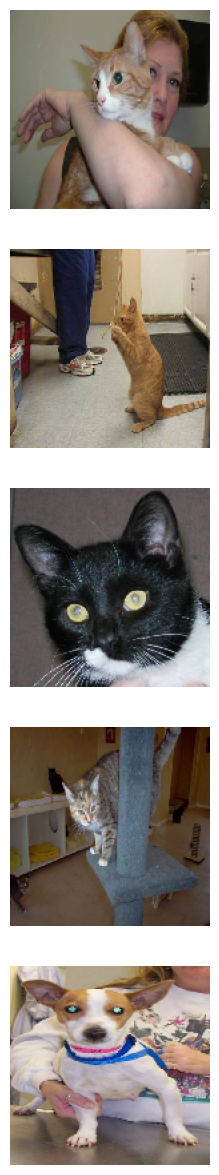

In [12]:
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])

In [13]:
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Found 2000 images belonging to 2 classes.


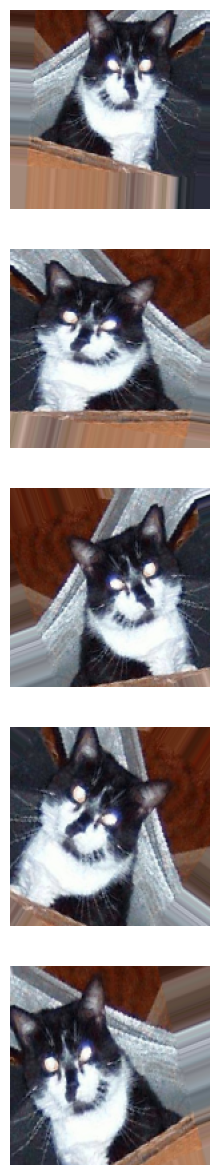

In [14]:
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [29]:
model = Sequential([
    Conv2D(input_shape = (IMG_HEIGHT,IMG_WIDTH,3),kernel_size=(3,3),filters=32,activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(filters= 64, kernel_size=(3,3),activation= 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(filters= 64, kernel_size=(3,3),activation= 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(filters= 128, kernel_size=(3,3),activation= 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(265,activation = 'relu'),
    Dense(1,activation='sigmoid')
])
model.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_16 (Conv2D)           (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_17 (MaxPooling (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_18 (Conv2D)           (None, 34, 34, 64)        36928     
_________________________________________________________________
max_pooling2d_18 (MaxPooling (None, 17, 17, 64)        0         
_________________________________________________________________
conv2d_19 (Conv2D)           (None, 15, 15, 128)      

In [30]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['acc'])

In [31]:
history = model.fit(
    x=train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=total_val // batch_size
)

Epoch 1/15
15/15 [==============================] - 62s 4s/step - loss: 0.7067 - acc: 0.5000 - val_loss: 0.6915 - val_acc: 0.5056
Epoch 2/15
15/15 [==============================] - 49s 3s/step - loss: 0.6916 - acc: 0.5198 - val_loss: 0.6870 - val_acc: 0.4989
Epoch 3/15
15/15 [==============================] - 47s 3s/step - loss: 0.6833 - acc: 0.5556 - val_loss: 0.6516 - val_acc: 0.6496
Epoch 4/15
15/15 [==============================] - 53s 4s/step - loss: 0.6732 - acc: 0.5823 - val_loss: 0.6495 - val_acc: 0.6373
Epoch 5/15
15/15 [==============================] - 42s 3s/step - loss: 0.6685 - acc: 0.5962 - val_loss: 0.6450 - val_acc: 0.6373
Epoch 6/15
15/15 [==============================] - 49s 3s/step - loss: 0.6505 - acc: 0.6191 - val_loss: 0.6735 - val_acc: 0.5748
Epoch 7/15
15/15 [==============================] - 48s 3s/step - loss: 0.6476 - acc: 0.6266 - val_loss: 0.6317 - val_acc: 0.6228
Epoch 8/15
15/15 [==============================] - 51s 3s/step - loss: 0.6344 - acc: 0.63

In [40]:
probabilities = model.predict(test_data_gen)

In [36]:
argpred = [0 if i<0.5 else 1 for i in pred]

In [42]:
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 
            0, 0, 0, 0, 0, 0]

correct = 0

for probability, answer in zip(probabilities, answers):
  if np.round(probability) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

Your model correctly identified 74.0% of the images of cats and dogs.
You passed the challenge!
